Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
customers = pd.read_csv("customers_clean.csv")
orders = pd.read_csv("orders_clean.csv")
order_items = pd.read_csv("order_items_clean.csv")
products = pd.read_csv("products_clean.csv")
marketing = pd.read_csv("marketing_clean.csv")
feedback = pd.read_csv("feedback_clean.csv")

Calculate High-Level KPIs

In [3]:
total_customers = customers['customer_id'].nunique()
total_customers

2500

In [5]:
total_orders = orders['order_id'].nunique()
total_orders

5000

In [8]:
total_revenue = orders['order_total'].sum()
total_revenue

np.float64(11009308.5)

In [9]:
avg_order_revenue = orders['order_total'].mean()
avg_order_revenue

np.float64(2201.8617)

In [10]:
total_products = products['product_id'].nunique()
total_products

268

In [12]:
avg_rating = feedback['rating'].mean()
avg_rating

np.float64(3.3444)

In [14]:
total_campaigns = marketing['campaign_id'].nunique()
total_campaigns

5400

Customer Analysis

In [16]:
total_customers

2500

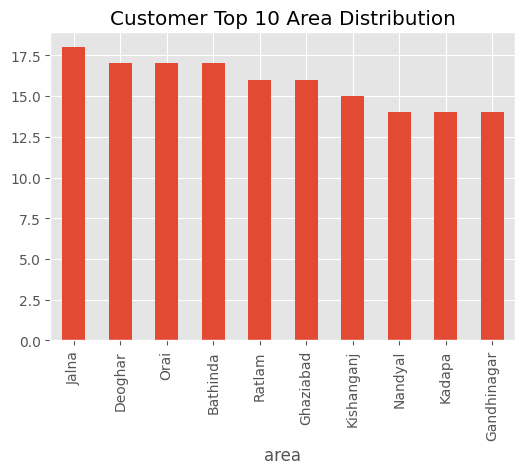

In [20]:
customers['area'].value_counts().head(10).plot(kind='bar', figsize=(6,4))
plt.title("Customer Top 10 Area Distribution")
plt.show()

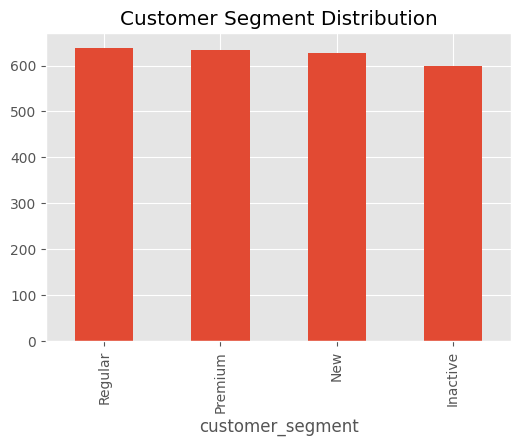

In [22]:
customers['customer_segment'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Customer Segment Distribution")
plt.show()

Order Analysis

In [35]:
total_orders

5000

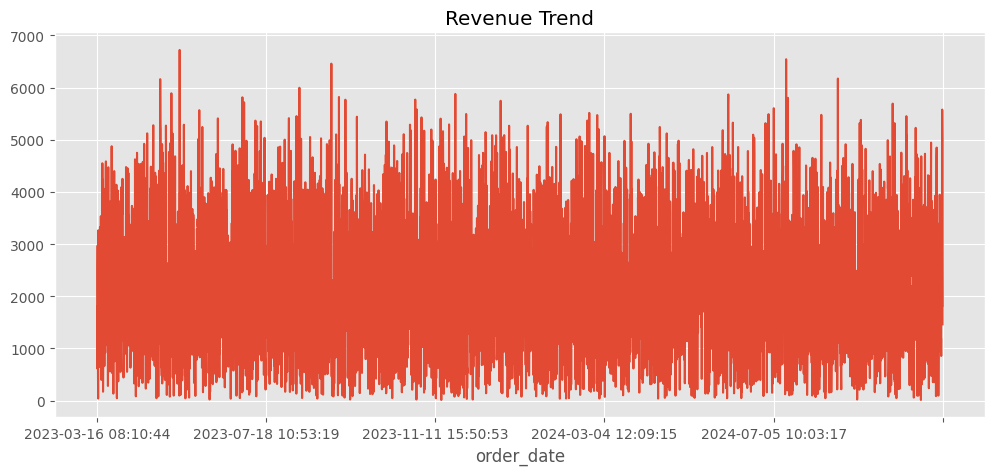

In [24]:
orders.groupby('order_date')['order_total'].sum().plot(figsize=(12,5))
plt.title("Revenue Trend")
plt.show()

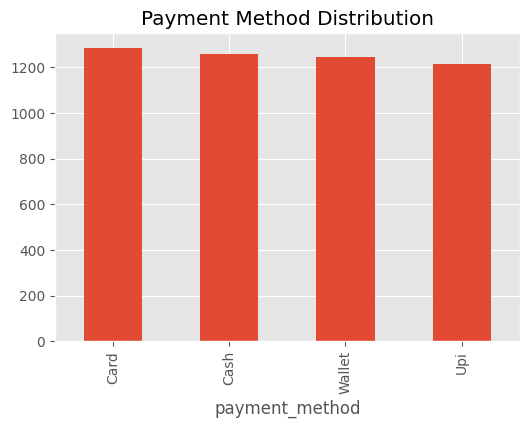

In [36]:
orders['payment_method'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Payment Method Distribution")
plt.show()

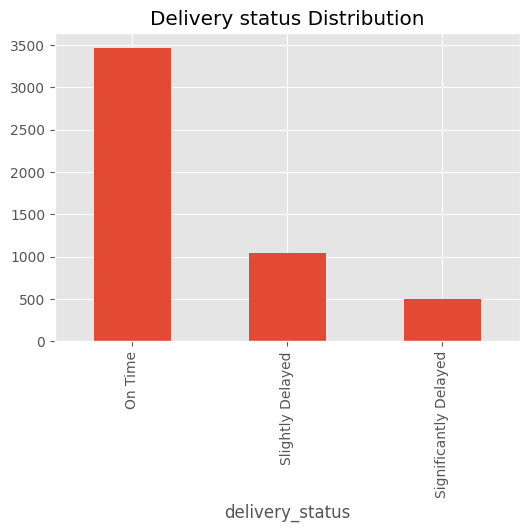

In [37]:
orders['delivery_status'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Delivery status Distribution")
plt.show()

Product Analysis

In [38]:
total_products

268

In [27]:
products

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55
...,...,...,...,...,...,...,...,...,...,...
263,444361,Pain Reliever,Pharmacy,"Prakash, Bawa and Kale",822.63,1028.29,20.0,365,20,71
264,679284,Cough Syrup,Pharmacy,Pant LLC,877.89,1097.36,20.0,365,28,95
265,240179,Cough Syrup,Pharmacy,Ram-Suri,90.56,113.20,20.0,365,20,56
266,673058,Cough Syrup,Pharmacy,Balan-Madan,765.76,957.20,20.0,365,30,94


In [28]:
order_items

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55
...,...,...,...,...
4995,1669690997,925482,3,475.04
4996,8340761903,124290,2,39.65
4997,5936301790,491314,3,973.44
4998,5710579377,319388,2,657.80


In [29]:
merged = order_items.merge(products,on='product_id')

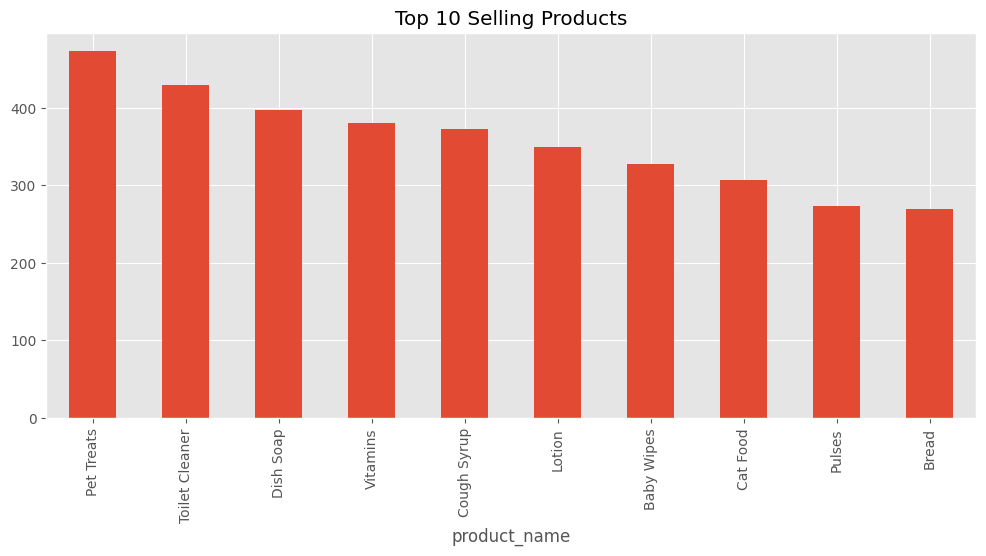

In [30]:
merged.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar',figsize=(12,5))
plt.title("Top 10 Selling Products")
plt.show()

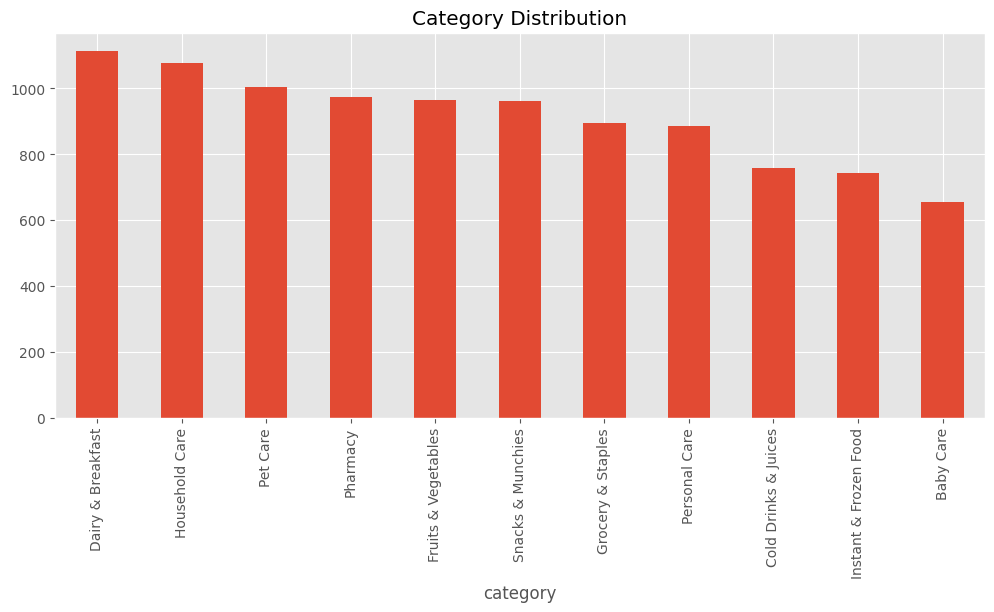

In [34]:
merged.groupby('category')['quantity'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(12,5))
plt.title("Category Distribution")
plt.show()

Marketing Analysis

In [39]:
total_campaigns

5400

In [40]:
marketing['CTR'] = (marketing['clicks']/marketing['impressions'])

In [42]:
marketing['conversion_rate'] = (marketing['conversions']/marketing['clicks'])

In [45]:
marketing['ROAS'] = (marketing['revenue_generated']/marketing['spend'])

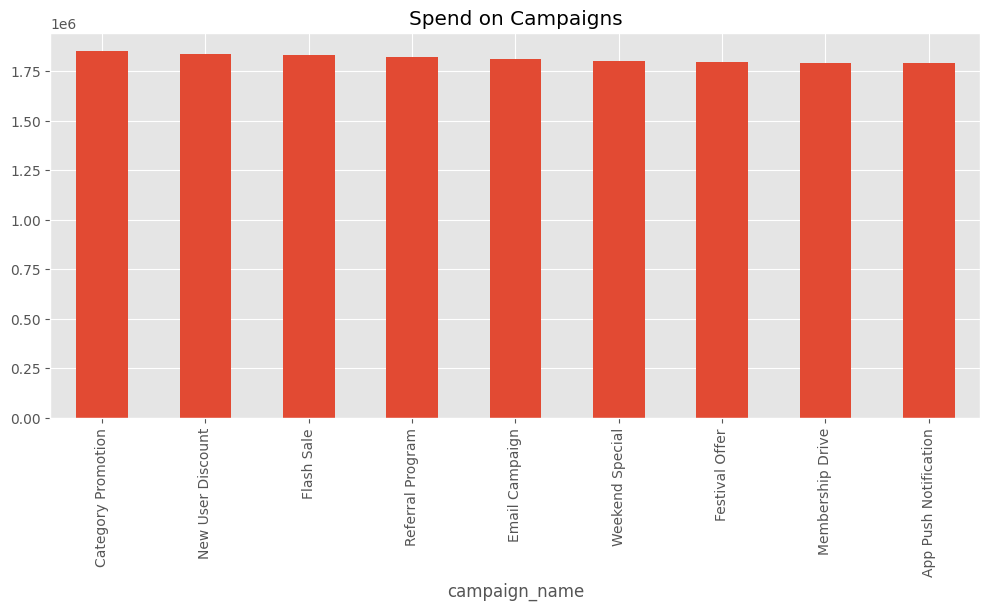

In [48]:
marketing.groupby('campaign_name')['spend'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(12,5))
plt.title("Spend on Campaigns")
plt.show()

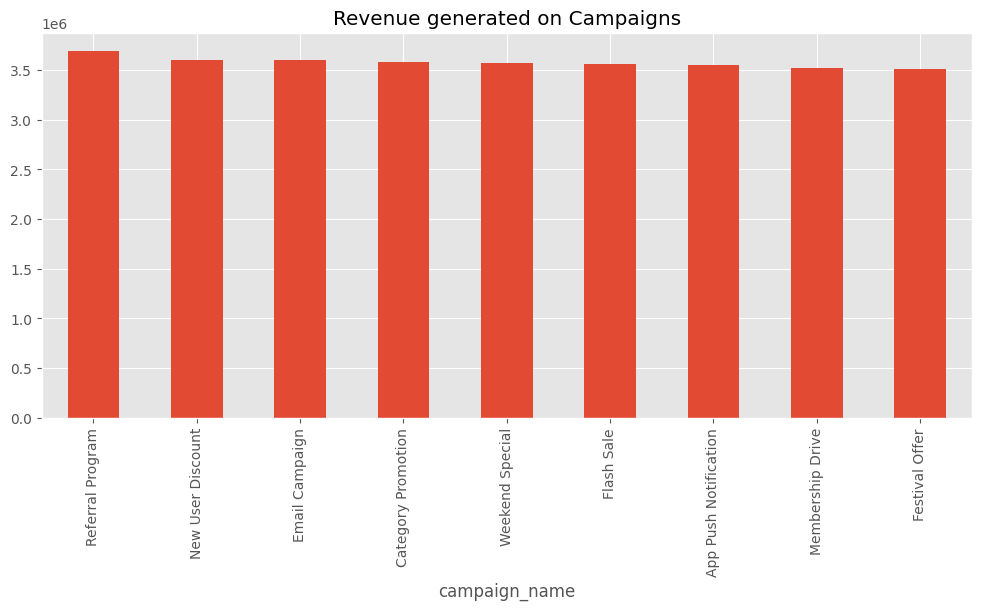

In [49]:
marketing.groupby('campaign_name')['revenue_generated'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(12,5))
plt.title("Revenue generated on Campaigns")
plt.show()

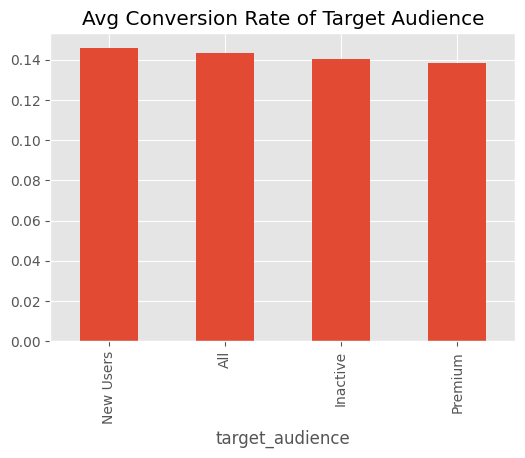

In [51]:
marketing.groupby('target_audience')['conversion_rate'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(6,4))
plt.title("Avg Conversion Rate of Target Audience")
plt.show()

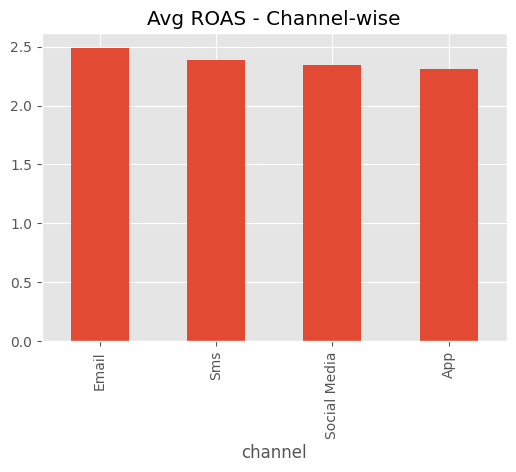

In [52]:
marketing.groupby('channel')['ROAS'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(6,4))
plt.title("Avg ROAS - Channel-wise")
plt.show()

Customer Feedback Analysis

In [53]:
avg_rating

np.float64(3.3444)

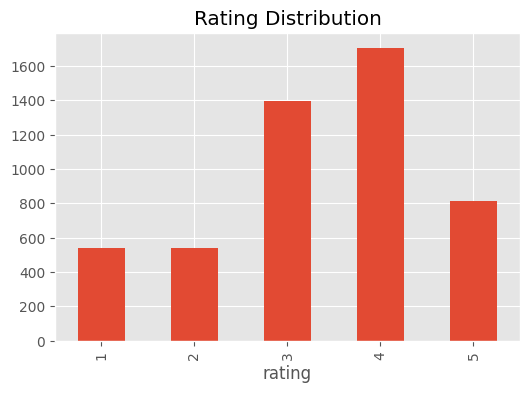

In [56]:
feedback['rating'].value_counts().sort_index().plot(kind='bar',figsize=(6,4))
plt.title("Rating Distribution")
plt.show()

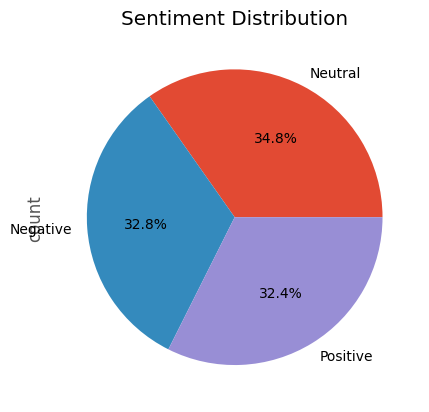

In [57]:
feedback['sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

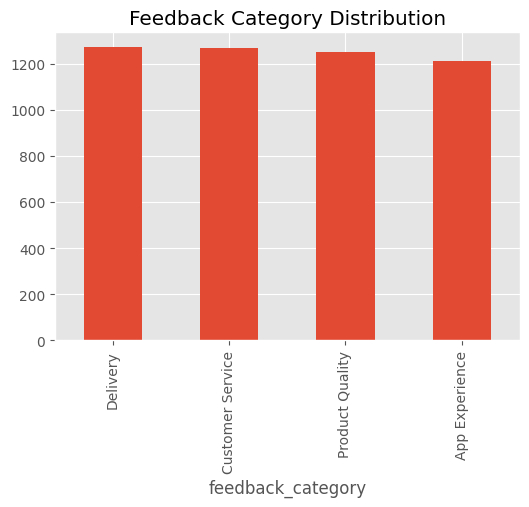

In [58]:
feedback['feedback_category'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Feedback Category Distribution")
plt.show()

Correlation Analysis

In [59]:
numeric = marketing.select_dtypes(include='number')
corr = numeric.corr()
corr

,campaign_id,impressions,clicks,conversions,spend,revenue_generated,roas,CTR,conversion_rate,ROAS
campaign_id,1.000000,0.004003,-0.010403,0.001323,-0.004931,0.016608,0.003993,-0.002792,0.004690,0.013578
impressions,0.004003,1.000000,0.002873,-0.000508,-0.002230,0.000548,-0.005031,-0.656970,0.016574,-0.001145
clicks,-0.010403,0.002873,1.000000,-0.002899,-0.002261,0.002314,-0.031176,0.507685,-0.660596,0.011153
conversions,0.001323,-0.000508,-0.002899,1.000000,-0.014747,-0.010851,-0.000676,0.006894,0.508581,0.003325
spend,-0.004931,-0.002230,-0.002261,-0.014747,1.000000,-0.013561,0.003918,-0.003192,0.001698,-0.686819
revenue_generated,0.016608,0.000548,0.002314,-0.010851,-0.013561,1.000000,-0.008423,-0.006145,-0.019760,0.605021
roas,0.003993,-0.005031,-0.031176,-0.000676,0.003918,-0.008423,1.000000,-0.007585,0.031853,-0.000110
CTR,-0.002792,-0.656970,0.507685,0.006894,-0.003192,-0.006145,-0.007585,1.000000,-0.335052,0.004459
conversion_rate,0.004690,0.016574,-0.660596,0.508581,0.001698,-0.019760,0.031853,-0.335052,1.000000,-0.018054
ROAS,0.013578,-0.001145,0.011153,0.003325,-0.686819,0.605021,-0.000110,0.004459,-0.018054,1.000000


Outlier Detection

<Axes: >

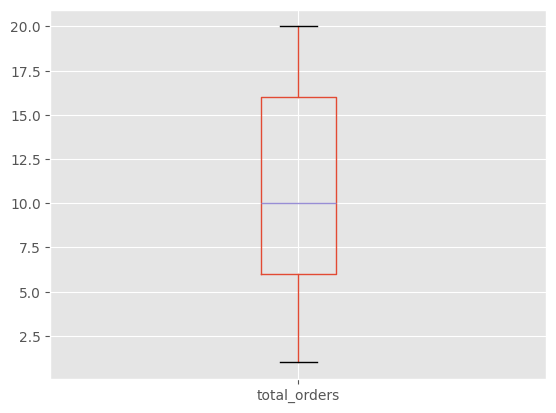

In [61]:
customers.boxplot(column='total_orders')

<Axes: >

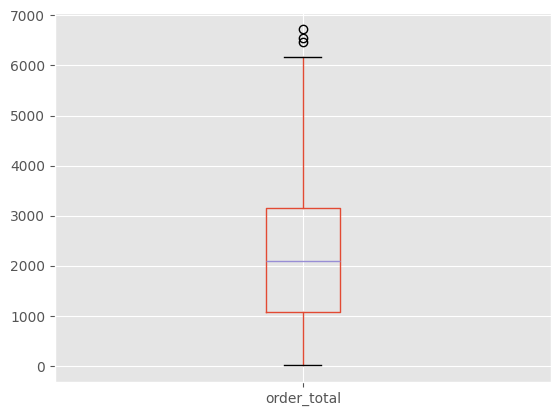

In [62]:
orders.boxplot(column='order_total')

<Axes: >

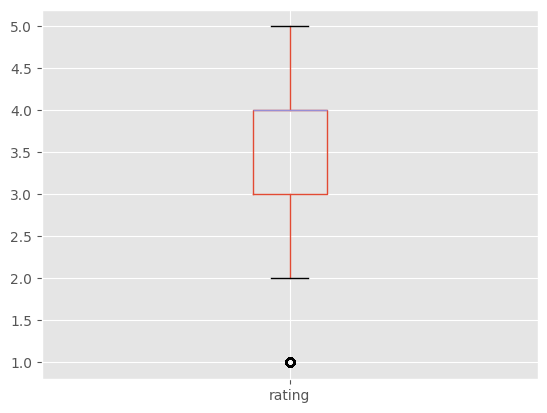

In [69]:
feedback.boxplot(column='rating')

<Axes: >

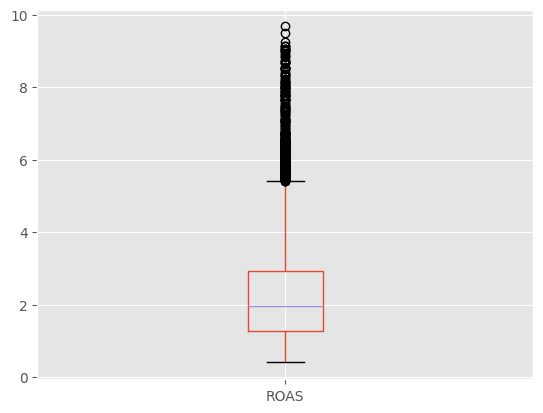

In [72]:
marketing.boxplot('ROAS')